In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys         
import xarray as xr
import NooneCurves as NC 
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import gc

In [2]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [3]:
inst = 'TROPOMI'
band = 'EQ'
ON1 = 62 
CE1 = 142
ON2 = 247
CE2 = 341

tlist = []
for Y in range(2018,2020):
    print('running year: ',str(Y))
    tin = xr.open_dataset("/Volumes/New_5TB/ESA_F4R/tropomi2_merged/TROPOMI_merged_"+str(Y)+".nc")
    #tlist.append(tin.where((tin.lat < 12.) & (tin.lat > 5.) & (tin.lon < 31.) & (tin.lon > 10.),drop=True).load())
    tlist.append(tin.where((tin.lat < 5.) & (tin.lat > -5.) & (tin.lon < 29.) & (tin.lon > 8.),drop=True).load())
    #tlist.append(tin.where((tin.lat < -5.) & (tin.lat > -15.) & (tin.lon < 31.) & (tin.lon > 12.),drop=True).load())
    tin.close()
    del tin
sat_ds = xr.concat(tlist,dim='time')
sat_ds = sat_ds.rename({'time':'timedatum'})
del tlist
print(sat_ds)


running year:  2018
running year:  2019
<xarray.Dataset> Size: 5GB
Dimensions:       (timedatum: 955, scanline: 1630, ground_pixel: 215)
Coordinates:
  * timedatum     (timedatum) datetime64[ns] 8kB 2018-04-30T10:50:26 ... 2019...
  * scanline      (scanline) int32 7kB 1088 1089 1090 1091 ... 2715 2716 2717
  * ground_pixel  (ground_pixel) int64 2kB 0 1 2 3 4 5 ... 210 211 212 213 214
    lat           (timedatum, scanline, ground_pixel) float32 1GB nan ... 10.73
    lon           (timedatum, scanline, ground_pixel) float32 1GB nan ... 27.79
Data variables:
    deltad        (timedatum, scanline, ground_pixel) float32 1GB nan ... nan
    h2o_vmr       (timedatum, scanline, ground_pixel) float32 1GB nan ... nan


In [4]:
ON = ON1
CE = CE1
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)
pcesson = CE-(20*2)
cesson = CE-20
cess = CE
cesss = CE+20
print(pppon)


2


In [5]:
#S1 onset

mam_seas = {}
mam_seas['60-40 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pppon)&(sat_ds['timedatum.dayofyear']<pppon+20),drop=True)
mam_seas['40-20 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ppon)&(sat_ds['timedatum.dayofyear']<ppon+20),drop=True)
mam_seas['20 days to onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pon)&(sat_ds['timedatum.dayofyear']<pon+20),drop=True)
mam_seas['onset to 20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>on)&(sat_ds['timedatum.dayofyear']<on+20),drop=True)
mam_seas['20-40 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ons)&(sat_ds['timedatum.dayofyear']<ons+20),drop=True)
mam_seas['40-60 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>onss)&(sat_ds['timedatum.dayofyear']<onss+20),drop=True)

mam_seas['40-20 days pre-cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pcesson)&(sat_ds['timedatum.dayofyear']<pcesson+20),drop=True)
mam_seas['20 days to cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesson)&(sat_ds['timedatum.dayofyear']<cesson+20),drop=True)
mam_seas['cessation to post-20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cess)&(sat_ds['timedatum.dayofyear']<cess+20),drop=True)
mam_seas['post 20 days - post 40 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesss)&(sat_ds['timedatum.dayofyear']<cesss+20),drop=True)


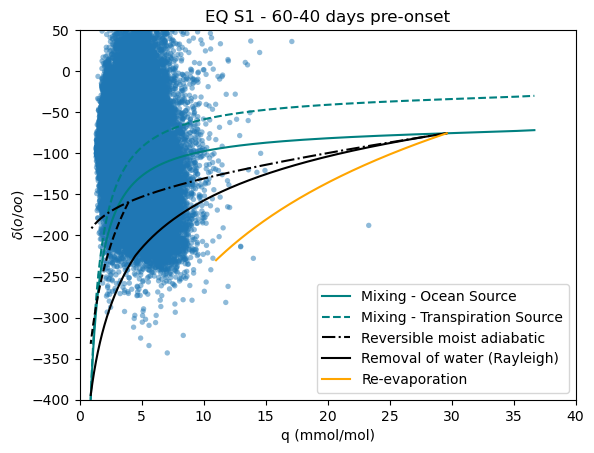

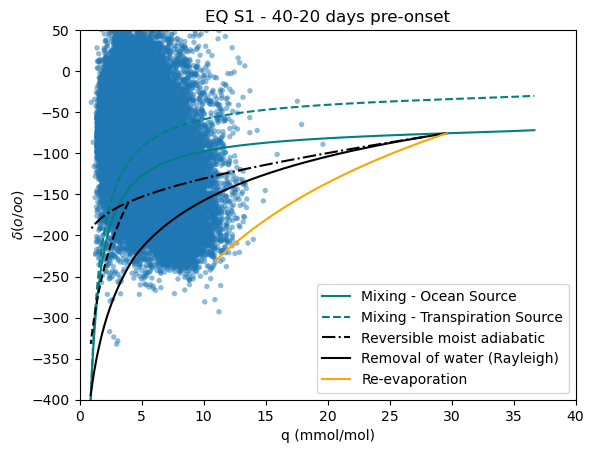

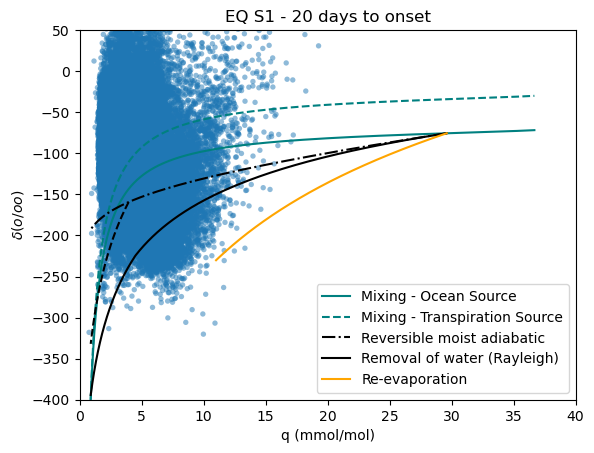

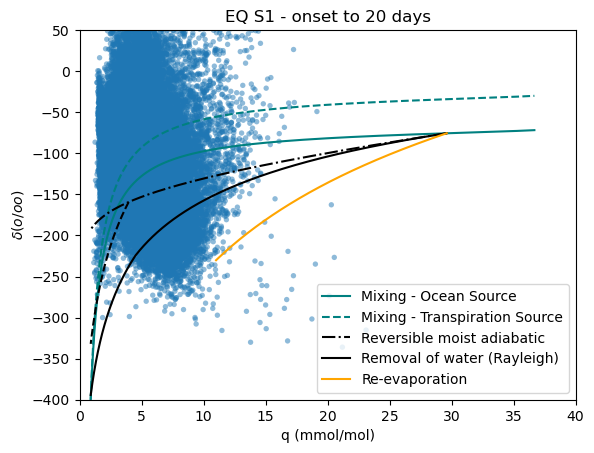

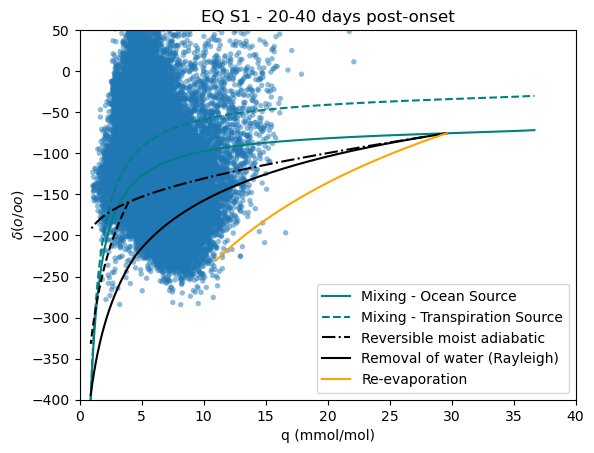

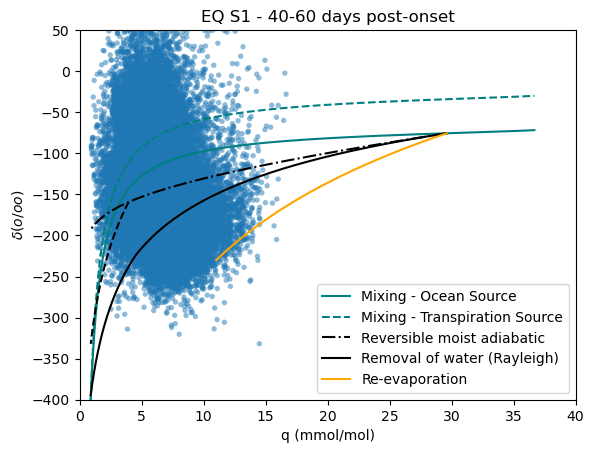

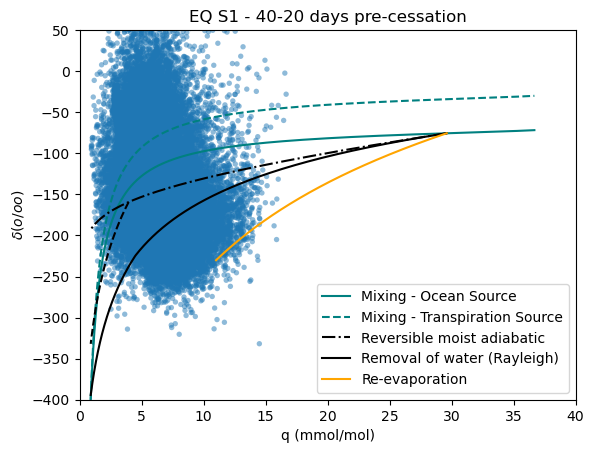

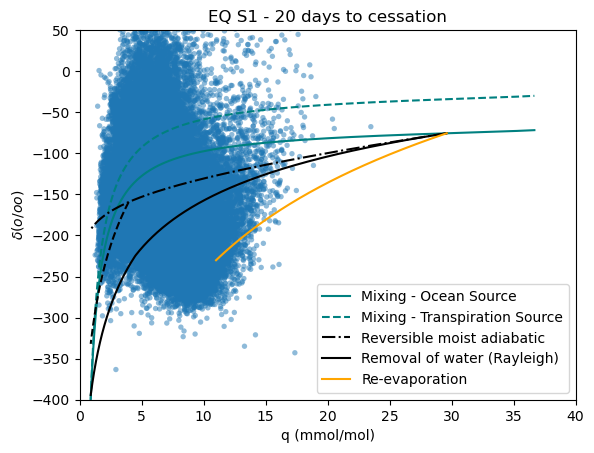

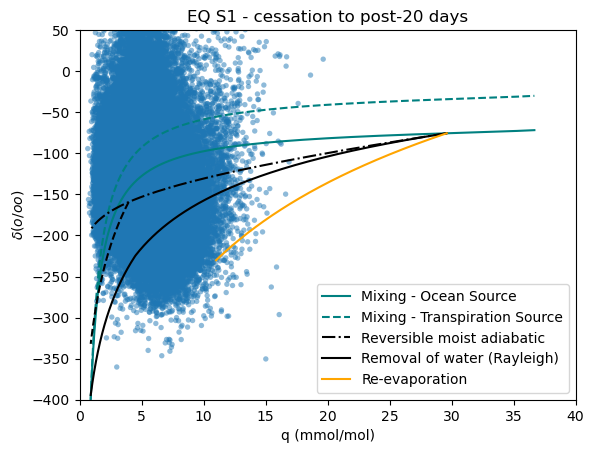

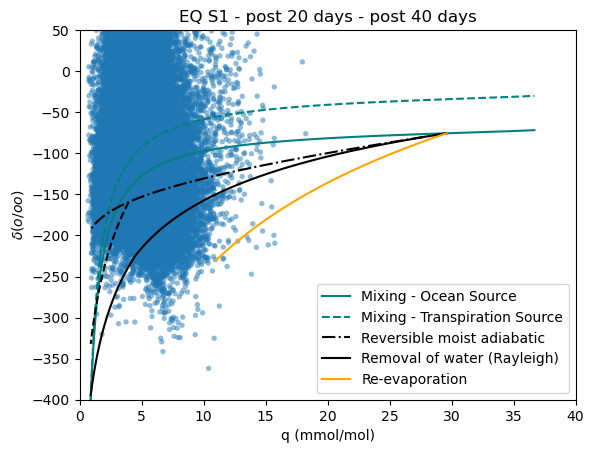

In [6]:
for s in mam_seas:
    
    deltaD = mam_seas[s]['deltad']
    qh2o = mam_seas[s]['h2o_vmr']
    
    
    plt.xlim(0,40)
    plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
    
    plt.legend(loc='best')
    plt.title(band+' S1 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S1_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()

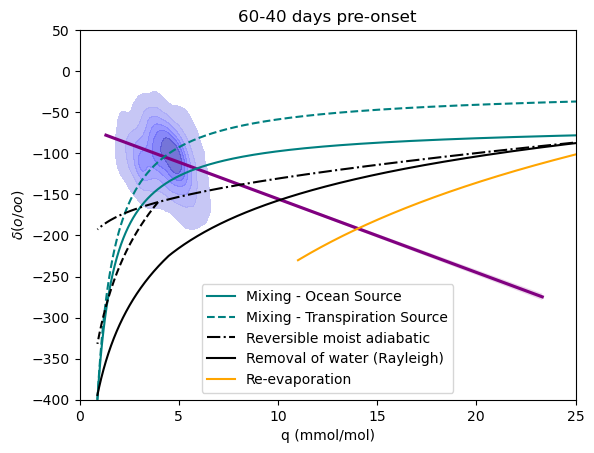

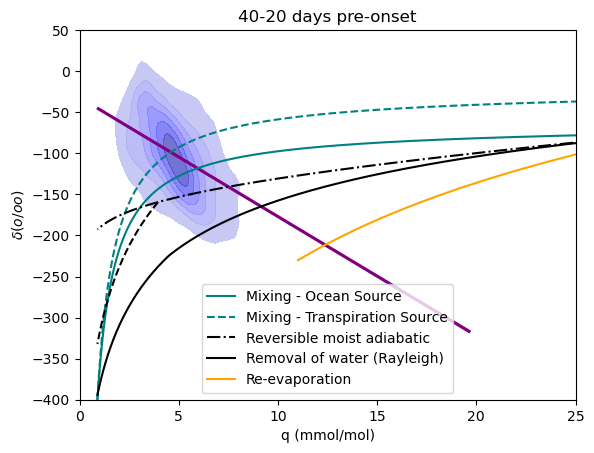

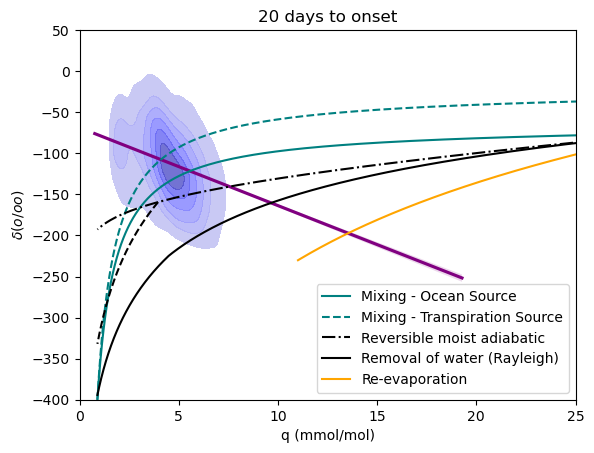

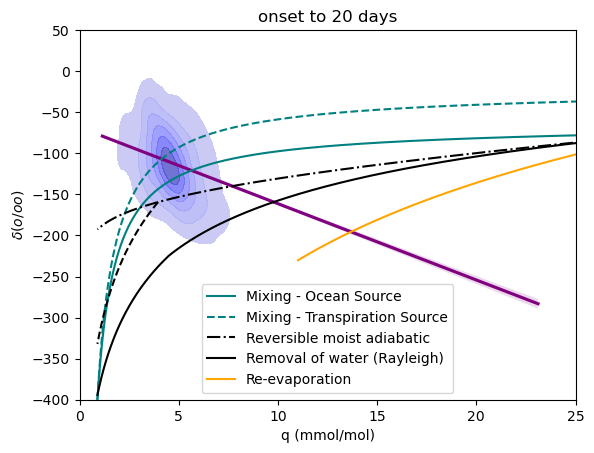

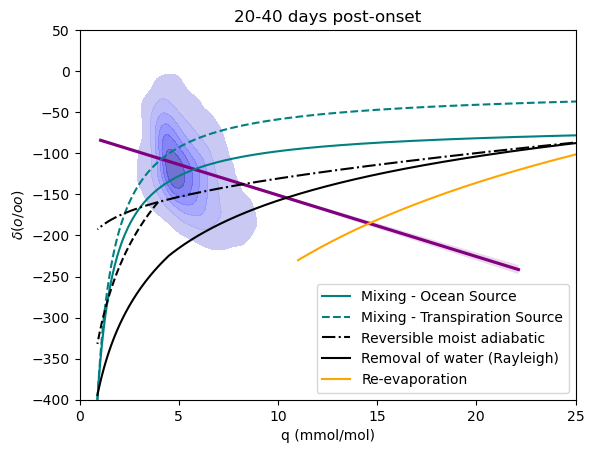

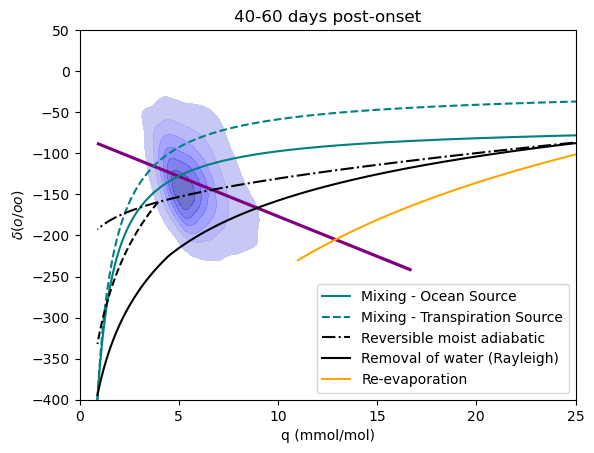

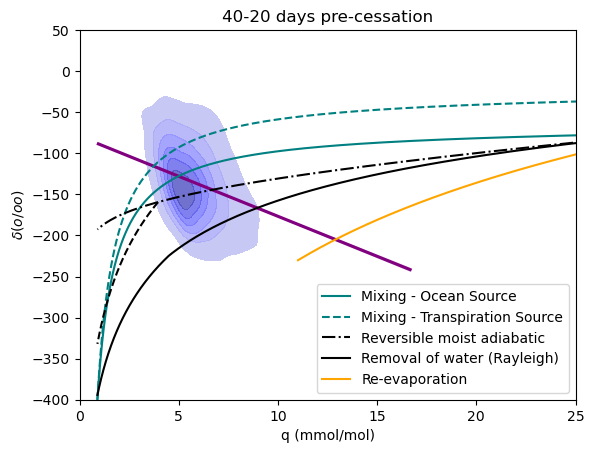

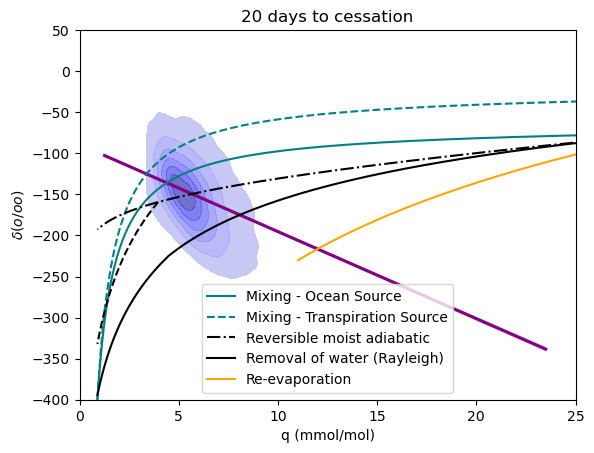

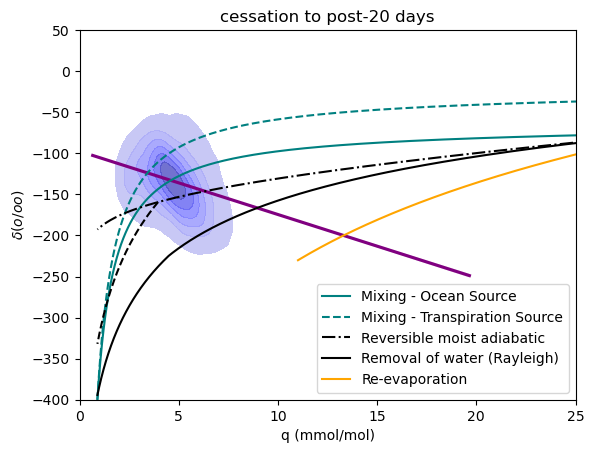

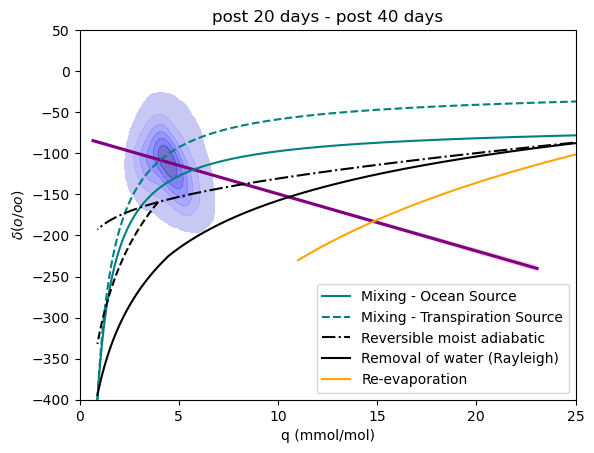

In [7]:
for s in mam_seas:
    
    df = mam_seas[s].to_dataframe()
    df['h2o_vmr'] = df['h2o_vmr']
    
    sns.kdeplot(data=df, x="h2o_vmr", y="deltad", fill=True, kind="kde", 
                alpha=0.8,color='blue',
                levels=7, thresh=.1)
    sns.regplot(data=df, x="h2o_vmr", y="deltad", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,25)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S1_'+s+'.png',transparent=True)

    plt.show()
    plt.clf()
    plt.close()

In [8]:
ON = ON2
CE = CE2
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)
pcesson = CE-(20*2)
cesson = CE-20
cess = CE
cesss = CE+20


In [9]:
#SON onset

son_seas = {}
son_seas['60-40 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pppon)&(sat_ds['timedatum.dayofyear']<pppon+20),drop=True)
son_seas['40-20 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ppon)&(sat_ds['timedatum.dayofyear']<ppon+20),drop=True)
son_seas['20 days to onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pon)&(sat_ds['timedatum.dayofyear']<pon+20),drop=True)
son_seas['onset to 20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>on)&(sat_ds['timedatum.dayofyear']<on+20),drop=True)
son_seas['20-40 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ons)&(sat_ds['timedatum.dayofyear']<ons+20),drop=True)
son_seas['40-60 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>onss)&(sat_ds['timedatum.dayofyear']<onss+20),drop=True)

son_seas['40-20 days pre-cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pcesson)&(sat_ds['timedatum.dayofyear']<pcesson+20),drop=True)
son_seas['20 days to cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesson)&(sat_ds['timedatum.dayofyear']<cesson+20),drop=True)
son_seas['cessation to post-20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cess)&(sat_ds['timedatum.dayofyear']<cess+20),drop=True)
son_seas['post 20 days - post 40 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesss)&(sat_ds['timedatum.dayofyear']<cesss+20),drop=True)

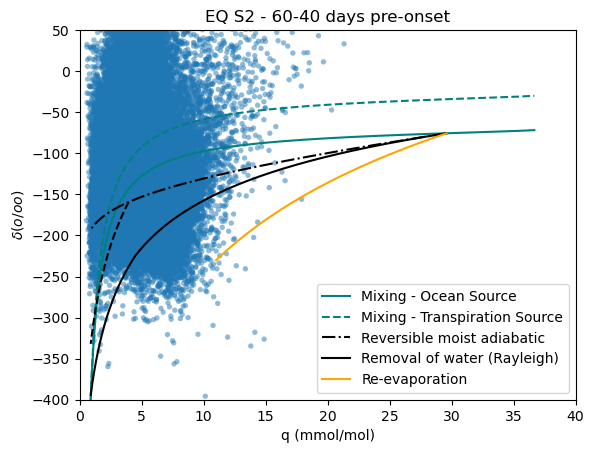

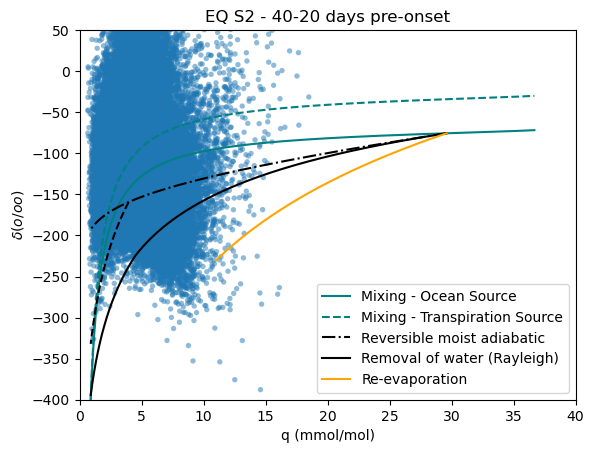

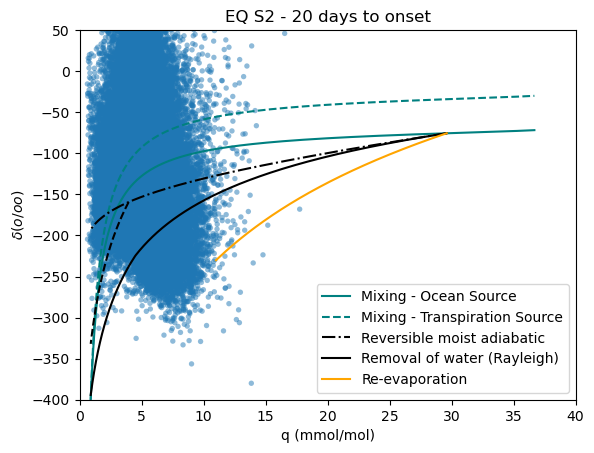

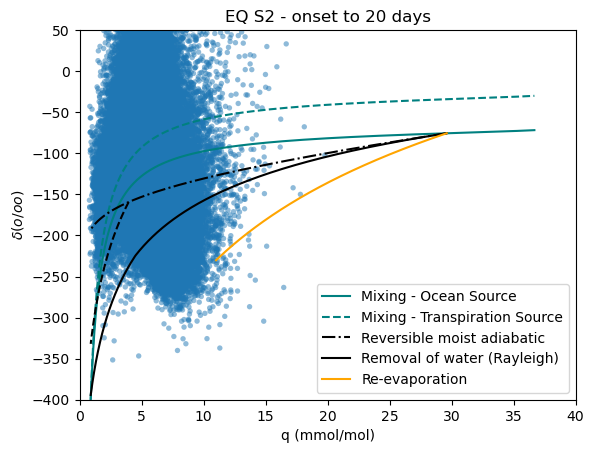

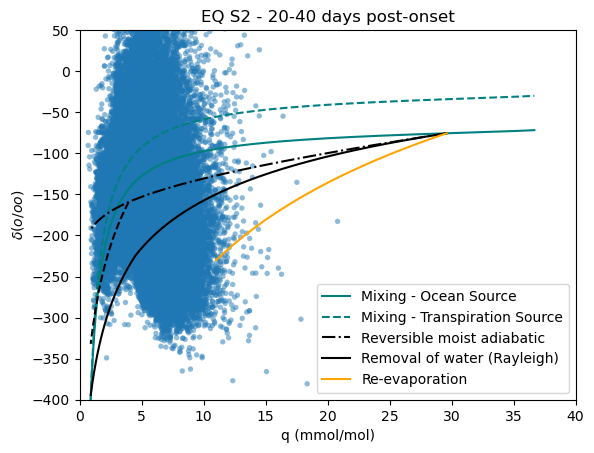

In [ ]:
for s in son_seas:
    
    deltaD = son_seas[s]['deltad']
    qh2o = son_seas[s]['h2o_vmr']
    
    plt.xlim(0,40)
    plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(band+' S2 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S2_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()
    

In [ ]:
for s in son_seas:
    
    df = son_seas[s].to_dataframe()
    df['h2o_vmr'] = df['h2o_vmr']
    
    sns.kdeplot(data=df, x="h2o_vmr", y="deltad", kind="kde", fill=True, 
                alpha=0.8,color='blue',
                levels=7, thresh=.1,)
    sns.regplot(data=df, x="h2o_vmr", y="deltad", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,25)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')


    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S2_'+s+'.png',transparent=True)

    plt.show()
    plt.clf()
    plt.close()

In [ ]:
sys.exit()

In [ ]:
#DJF = sat_ds.where((sat_ds['timedatum.month']>11)&(sat_ds['timedatum.month']<3),drop=True)
#JJA = sat_ds.where((sat_ds['timedatum.month']>5)&(sat_ds['timedatum.month']<9),drop=True)

ext_seas = {}
ext_seas['Dec'] = sat_ds.where((sat_ds['timedatum.month']==12),drop=True)
ext_seas['Feb'] = sat_ds.where((sat_ds['timedatum.month']==2),drop=True)
ext_seas['Jan'] = sat_ds.where((sat_ds['timedatum.month']==1),drop=True)
ext_seas['Jun'] = sat_ds.where((sat_ds['timedatum.month']==6),drop=True)
ext_seas['Jul'] = sat_ds.where((sat_ds['timedatum.month']==7),drop=True)
ext_seas['Aug'] = sat_ds.where((sat_ds['timedatum.month']==8),drop=True)
ext_seas['Sep'] = sat_ds.where((sat_ds['timedatum.month']==9),drop=True)
ext_seas['Oct'] = sat_ds.where((sat_ds['timedatum.month']==10),drop=True)


############

for s in ext_seas:
    
    df = ext_seas[s].to_dataframe()
    df['h2o_vmr'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", kind="kde", fill=True, alpha=0.8,color='purple')
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,30)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(band+' '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()


In [ ]:
sys.exit()

In [ ]:

for m in range(1,13):
    print(m)
    deltaD = sat_ds['deltaD'].groupby('timedatum.month')[m]
    qh2o = 1000.*sat_ds['H2O'].groupby('timedatum.month')[m]
    print(deltaD)
    #deltaD = iso_m['deltaD']
    #qh2o = 1000.*iso_m['H2O']
    plt.xlim(0,55)
    plt.ylim(-600,100)
    plt.scatter(qh2o,deltaD,s=1)

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plot_file = '/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/plot_noone_curves_'+str(m)+'.png'    # default file name for plots
    plt.title('Month: '+str(m))
    plt.savefig(plot_file)
    
    plt.show()
    plt.clf()


In [ ]:
deltaD_w = sat_ds['deltaD'].groupby('timedatum.weekofyear')
qh2o_w = sat_ds['H2O'].groupby('timedatum.weekofyear')
print(deltaD_w)
#deltaD_roll = tes_ds['deltaD'].rolling(timedatum=10, center=True)   
#deltaD_bin = tes_ds['deltaD'].resample(timedatum='10D')

for m in range(1,53):
    try:
        print(m)
        deltaD = deltaD_w[m]
        qh2o = 1000.*qh2o_w[m]
        print(deltaD)
        plt.xlim(0,55)
        plt.scatter(qh2o,deltaD,s=1)

        plot_file = '/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/plot_noone_curves_week_'+str(m)+'.png'    
        plt.title('Week: '+str(m))
        #plt.savefig(plot_file)

        NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
    
        plt.show()
        plt.clf()
    except:
        print('no week: ',m)